In [1]:
import kagglehub
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("blurredmachine/are-your-employees-burning-out")

100%|██████████| 425k/425k [00:00<00:00, 16.2MB/s]

Extracting files...


In [2]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['train.csv', 'sample_submission.csv', 'test.csv']


In [3]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['train.csv', 'sample_submission.csv', 'test.csv']


In [4]:
import pandas as pd
import os

# Construct the full path to train.csv
train_csv_path = os.path.join(path, 'train.csv')

# Read the train.csv file into a pandas DataFrame
df_train = pd.read_csv(train_csv_path)

# Display the first 5 rows of the DataFrame
display(df_train.head())

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [5]:
# Construct the full path to train.csv
train_csv_path = os.path.join(path, 'train.csv')

# Read the train.csv file into a pandas DataFrame
df_train = pd.read_csv(train_csv_path)

# Display the first 5 rows of the DataFrame
display(df_train.head())

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [6]:
# Construct the full path to train.csv
test_csv_path = os.path.join(path, 'test.csv')

# Read the train.csv file into a pandas DataFrame
df_test = pd.read_csv(test_csv_path)

# Display the first 5 rows of the DataFrame
display(df_test.head())

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score
0,fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7
1,fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2
2,fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9
3,fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6
4,fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4


In [7]:
# Construct the full path to train.csv
sample_submission_csv_path = os.path.join(path, 'sample_submission.csv')

# Read the train.csv file into a pandas DataFrame
df_sample_submission = pd.read_csv(sample_submission_csv_path)

# Display the first 5 rows of the DataFrame
display(df_sample_submission.head())

,Employee ID,Burn Rate
0,fffe32003000360033003200,0.16
1,fffe3700360033003500,0.36
2,fffe31003300320037003900,0.49
3,fffe32003400380032003900,0.20
4,fffe31003900340031003600,0.52


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [9]:
df_train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [10]:
df_train['Company Type'].unique()

array(['Service', 'Product'], dtype=object)

Supervised: Predict Burn Rate with regression<br>
1. What feature contributes most to burnout score<br>
2. Does WFH reduce burnout?<br>
Unsupervised: Cluster employees into burnout/workload profiles<br>
1. Are there clusters with more burnouts than others?<br>
2. how does service/product companies differ in cluster formation?<br>

Low risk: Burn Rate < 0.31<br>
Moderate risk: 0.31 ≤ Burn Rate < 0.59<br>
High risk: Burn Rate ≥ 0.59<br>

Predicting Employee Burnout and Identifying Workplace Risk Profiles Using Machine Learning

In [11]:
df_train['Date of Joining'].max()

'2008-12-31'

In [12]:
df_train['Date of Joining'].min()

'2008-01-01'

1. days_since_joined = 2008-12-31 - Date of Joining <br>
2. gender: Male = 1, Female = 0 <br>
3. company_type: Service = 1, Product = 0 <br>
4. is_wfh: Yes = 1, No = 0 <br>

In [13]:
import pandas as pd

df = df_train.copy()

# Drop ID
df = df.drop(columns=["Employee ID"])

# Convert date and create days_since_joined
df["Date of Joining"] = pd.to_datetime(df["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df["days_since_joined"] = (reference_date - df["Date of Joining"]).dt.days
df = df.drop(columns=["Date of Joining"])

# Binary encoding
df["gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["company_type"] = df["Company Type"].map({"Service": 1, "Product": 0})
df["is_wfh"] = df["WFH Setup Available"].map({"Yes": 1, "No": 0})

df = df.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

print(df.head())

   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0          2.0                  3.0                   3.8       0.16   
1          1.0                  2.0                   5.0       0.36   
2          2.0                  NaN                   5.8       0.49   
3          1.0                  1.0                   2.6       0.20   
4          3.0                  7.0                   6.9       0.52   

   days_since_joined  gender  company_type  is_wfh  
0                 92       0             1       0  
1                 31       1             1       1  
2                296       0             0       1  
3                 58       1             1       1  
4                160       0             1       0  


Missing values<br>
**burn rate**<br>
1. rows with burn rate missing should be dropped since this is the target variable for regression.<br>

**mental fatigue score, resource allocation**<br>
1. determine what kind of missingness is mental fatigue score, resource allocation <br>
2. run permutation test if necessary <br>
3. see what kind of imputation would introduce the least about of bias. (mean, median, mode, knn, gaussian distribution)<br>

In [14]:
df = df.copy()

missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

print(missing_summary)

                      missing_count  missing_percent
Mental Fatigue Score           2117             9.31
Resource Allocation            1381             6.07
Burn Rate                      1124             4.94
Designation                       0             0.00
days_since_joined                 0             0.00
gender                            0             0.00
company_type                      0             0.00
is_wfh                            0             0.00


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

dfc = df.copy()

# Missingness indicators
dfc["mfs_missing"] = dfc["Mental Fatigue Score"].isna().astype(int)
dfc["ra_missing"] = dfc["Resource Allocation"].isna().astype(int)

In [16]:
def tvd(p, q):
    p, q = p.align(q, fill_value=0)
    return 0.5 * np.abs(p - q).sum()

def categorical_perm_test(df, group_col, cat_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    observed_tab = pd.crosstab(df[group_col], df[cat_col], normalize='index')
    observed = tvd(observed_tab.loc[0], observed_tab.loc[1])

    stats = []
    for _ in range(n_perm):
        shuffled = df.copy()
        shuffled[cat_col] = rng.permutation(shuffled[cat_col].values)
        tab = pd.crosstab(shuffled[group_col], shuffled[cat_col], normalize='index')
        stat = tvd(tab.loc[0], tab.loc[1])
        stats.append(stat)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

In [17]:
def ks_perm_test(df, group_col, num_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    temp = df[[group_col, num_col]].dropna().copy()
    g0 = temp.loc[temp[group_col] == 0, num_col]
    g1 = temp.loc[temp[group_col] == 1, num_col]

    observed = ks_2samp(g0, g1).statistic

    stats = []
    for _ in range(n_perm):
        shuffled = temp.copy()
        shuffled[num_col] = rng.permutation(shuffled[num_col].values)
        g0s = shuffled.loc[shuffled[group_col] == 0, num_col]
        g1s = shuffled.loc[shuffled[group_col] == 1, num_col]
        stats.append(ks_2samp(g0s, g1s).statistic)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

Test statistic<br>
categorical: TVD(total variance distance) : distance measure for categorical distribution<br>
numerical: K-S(Kolmogorov-Smirnov statistic) : difference between numerical distribution<br>

We used TVD for categorical features because it measures differences in category proportions across the missing and non-missing groups, and we used the K-S statistic for numerical features because it compares the full distributions rather than only their means.

In [18]:
cat_cols = ["gender", "company_type", "is_wfh"]
num_cols = ["Designation", "days_since_joined", "Burn Rate"]

results = []

for target_missing in ["mfs_missing", "ra_missing"]:
    for col in cat_cols:
        stat, pval = categorical_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "categorical_TVD", stat, pval])

    for col in num_cols:
        stat, pval = ks_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "numeric_KS", stat, pval])

results_df = pd.DataFrame(results, columns=["missing_var", "tested_against", "test", "stat", "p_value"])
results_df = results_df.sort_values(["missing_var", "p_value"])
results_df

,missing_var,tested_against,test,stat,p_value
1,mfs_missing,company_type,categorical_TVD,0.011085,0.311344
0,mfs_missing,gender,categorical_TVD,0.010365,0.374313
3,mfs_missing,Designation,numeric_KS,0.013300,0.404298
2,mfs_missing,is_wfh,categorical_TVD,0.007997,0.499250
5,mfs_missing,Burn Rate,numeric_KS,0.016924,0.572714
4,mfs_missing,days_since_joined,numeric_KS,0.013029,0.854573
7,ra_missing,company_type,categorical_TVD,0.021132,0.118941
6,ra_missing,gender,categorical_TVD,0.009139,0.514243
10,ra_missing,days_since_joined,numeric_KS,0.019523,0.657671
11,ra_missing,Burn Rate,numeric_KS,0.018601,0.662669


Mental Fatigue Score: MCAR-consistent<br>
Resource Allocation: MCAR-consistent<br>

Mental fatigue score & resource allocation is closer to MCAR since none of the p-values were small enough to be significant.<br>

Although, mental fatigue score could be NMAR since workers with extremely high mental fatigue score would be hesitant to share it, we can not test for this with the data.<br>

For MCAR, empirical probabilistic imputation is the strongest fit. You fill missing values by randomly sampling from the observed values in that same column. Under MCAR this method gives unbiased estimates of the true mean and variance, unlike single-value imputation.

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Start from raw dataframe
df_clean = df_train.copy()

# Drop Employee ID
df_clean = df_clean.drop(columns=["Employee ID"])

# Convert Date of Joining to days_since_joined using 2008-12-31 as reference
df_clean["Date of Joining"] = pd.to_datetime(df_clean["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df_clean["days_since_joined"] = (reference_date - df_clean["Date of Joining"]).dt.days
df_clean = df_clean.drop(columns=["Date of Joining"])

# Binary encoding
# gender: Male = 1, Female = 0
# company_type: Service = 1, Product = 0
# is_wfh: Yes = 1, No = 0
df_clean["gender"] = df_clean["Gender"].map({"Male": 1, "Female": 0})
df_clean["company_type"] = df_clean["Company Type"].map({"Service": 1, "Product": 0})
df_clean["is_wfh"] = df_clean["WFH Setup Available"].map({"Yes": 1, "No": 0})

df_clean = df_clean.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

# Columns to impute
cols_to_impute = ["Mental Fatigue Score", "Resource Allocation"]

# Continuous columns to scale
scale_cols = ["Designation", "Resource Allocation", "Mental Fatigue Score", "days_since_joined"]

# -----------------------------
# Median-imputed + scaled dataset
# -----------------------------
df_median = df_clean.copy()
for col in cols_to_impute:
    df_median[col] = df_median[col].fillna(df_median[col].median())

scaler_median = StandardScaler()
df_median[scale_cols] = scaler_median.fit_transform(df_median[scale_cols])

# -----------------------------
# Empirical probabilistic-imputed + scaled dataset
# -----------------------------
df_prob = df_clean.copy()
rng = np.random.default_rng(42)

for col in cols_to_impute:
    missing_mask = df_prob[col].isna()
    observed_values = df_prob.loc[~missing_mask, col].values
    df_prob.loc[missing_mask, col] = rng.choice(
        observed_values,
        size=missing_mask.sum(),
        replace=True
    )

scaler_prob = StandardScaler()
df_prob[scale_cols] = scaler_prob.fit_transform(df_prob[scale_cols])

print("Median-imputed + scaled dataset preview:")
print(df_median.head())

print("\nProbabilistic-imputed + scaled dataset preview:")
print(df_prob.head())

Median-imputed + scaled dataset preview:
   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0    -0.157451            -0.730698             -1.062437       0.16   
1    -1.038415            -1.233872             -0.406671       0.36   
2    -0.157451            -0.227523              0.030506       0.49   
3    -1.038415            -1.737046             -1.718203       0.20   
4     0.723514             1.282000              0.631625       0.52   

   days_since_joined  gender  company_type  is_wfh  
0          -0.860076       0             1       0  
1          -1.439121       1             1       1  
2           1.076402       0             0       1  
3          -1.182823       1             1       1  
4          -0.214584       0             1       0  

Probabilistic-imputed + scaled dataset preview:
   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0    -0.157451            -0.722391             -1.002314       0.16   
1    -1.038415 

EDA for df_prob

Shape: (22750, 8)

Data types:
Designation             float64
Resource Allocation     float64
Mental Fatigue Score    float64
Burn Rate               float64
days_since_joined       float64
gender                    int64
company_type              int64
is_wfh                    int64
dtype: object

Summary statistics:
        Designation  Resource Allocation  Mental Fatigue Score     Burn Rate  \
count  2.275000e+04         2.275000e+04          2.275000e+04  21626.000000   
mean   2.011383e-16        -2.134751e-16         -3.463701e-16      0.452005   
std    1.000022e+00         1.000022e+00          1.000022e+00      0.198226   
min   -1.919379e+00        -1.698596e+00         -2.980486e+00      0.000000   
25%   -1.038415e+00        -7.223914e-01         -6.379140e-01      0.310000   
50%   -1.574506e-01        -2.342891e-01          9.088606e-02      0.450000   
75%    7.235137e-01         7.419155e-01          7.155718e-01      0.590000   
max    2.485442e+00         2.694325e+

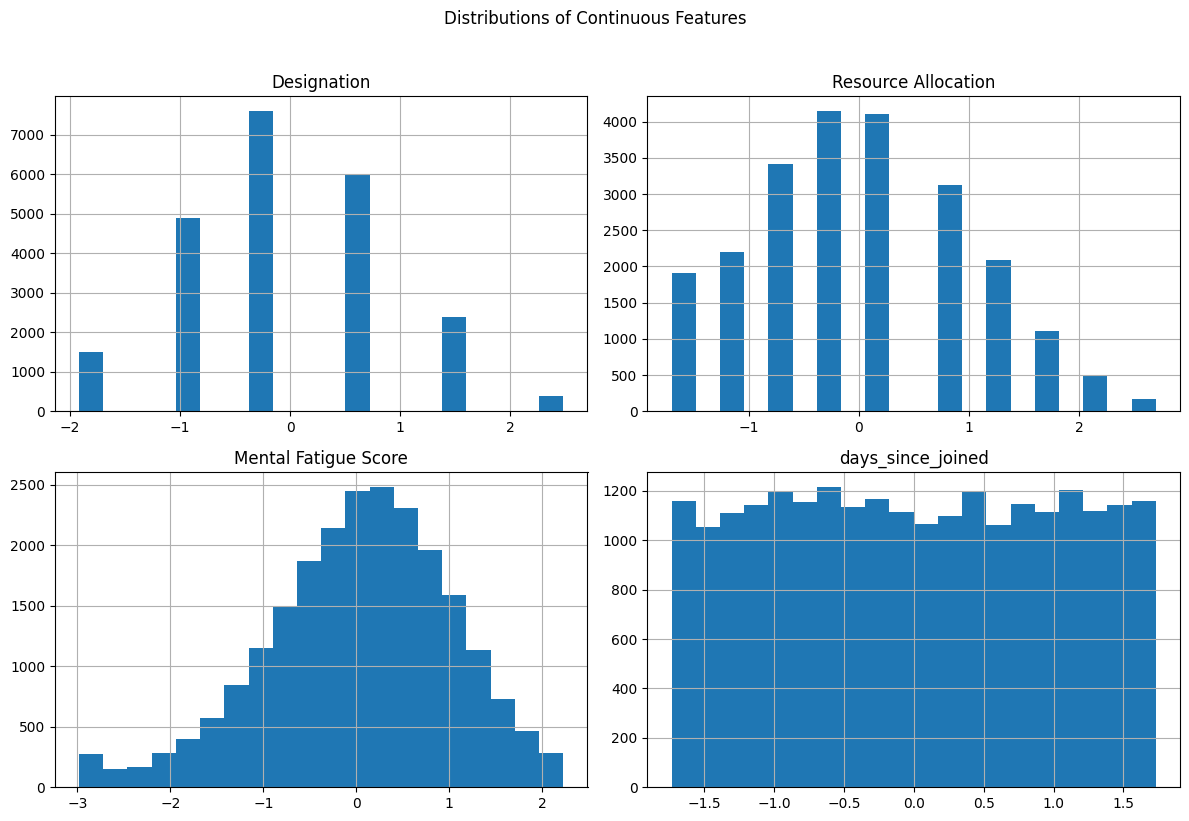

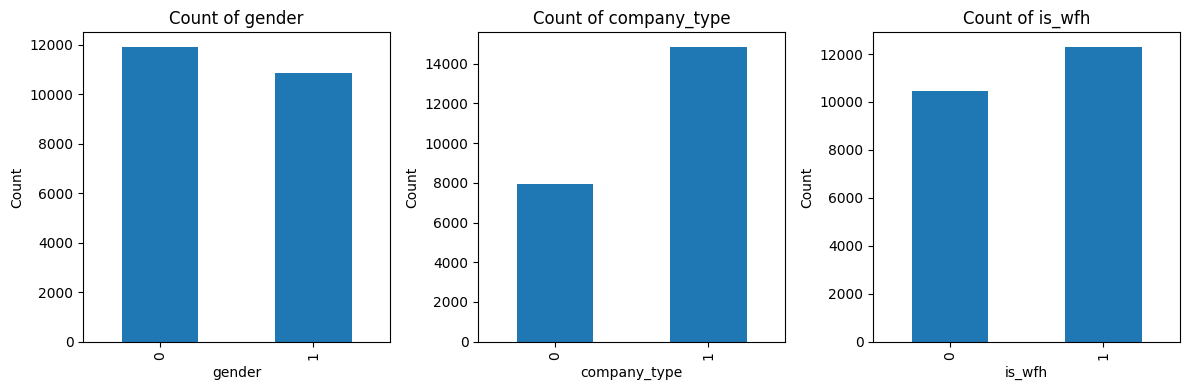


Correlation matrix:
                      Designation  Resource Allocation  Mental Fatigue Score  \
Designation              1.000000             0.826534              0.625200   
Resource Allocation      0.826534             1.000000              0.682798   
Mental Fatigue Score     0.625200             0.682798              1.000000   
Burn Rate                0.737556             0.805958              0.860189   
days_since_joined        0.000930             0.001335             -0.003235   
gender                   0.113295             0.136554              0.132707   
company_type             0.006095             0.007664             -0.000467   
is_wfh                  -0.229720            -0.266572             -0.250503   

                      Burn Rate  days_since_joined    gender  company_type  \
Designation            0.737556           0.000930  0.113295      0.006095   
Resource Allocation    0.805958           0.001335  0.136554      0.007664   
Mental Fatigue Score   0

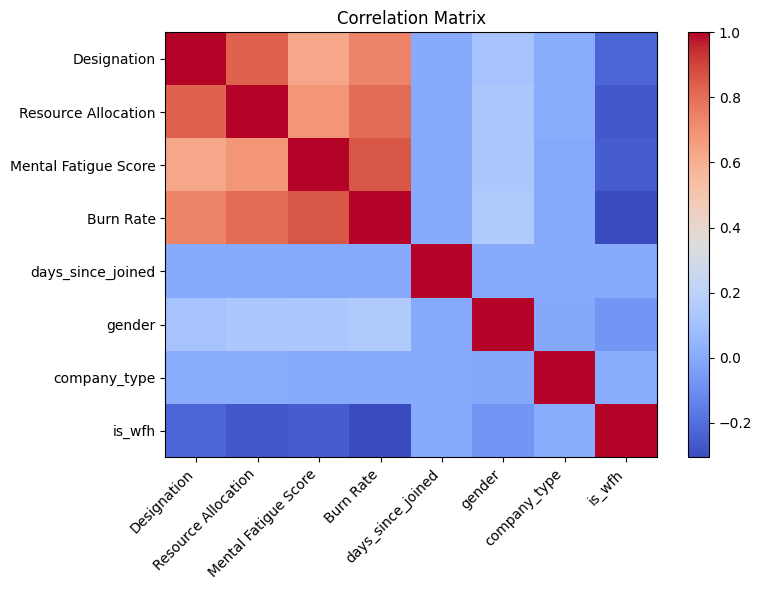

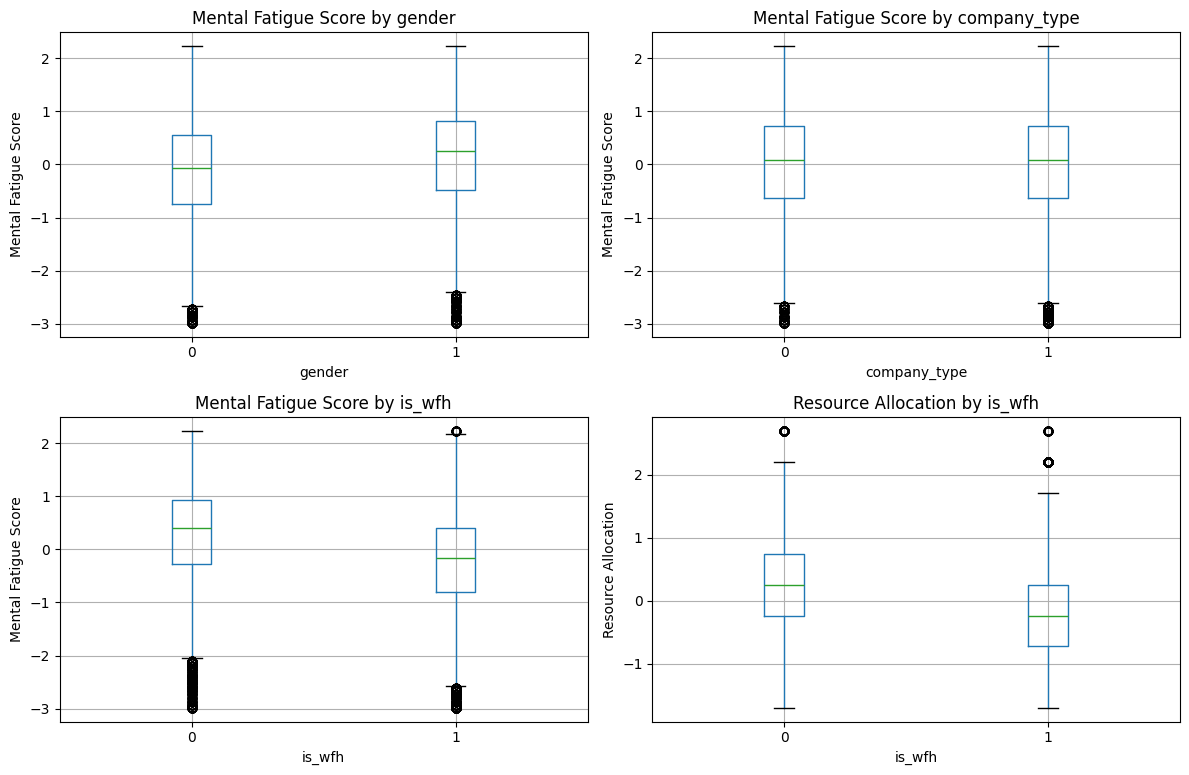

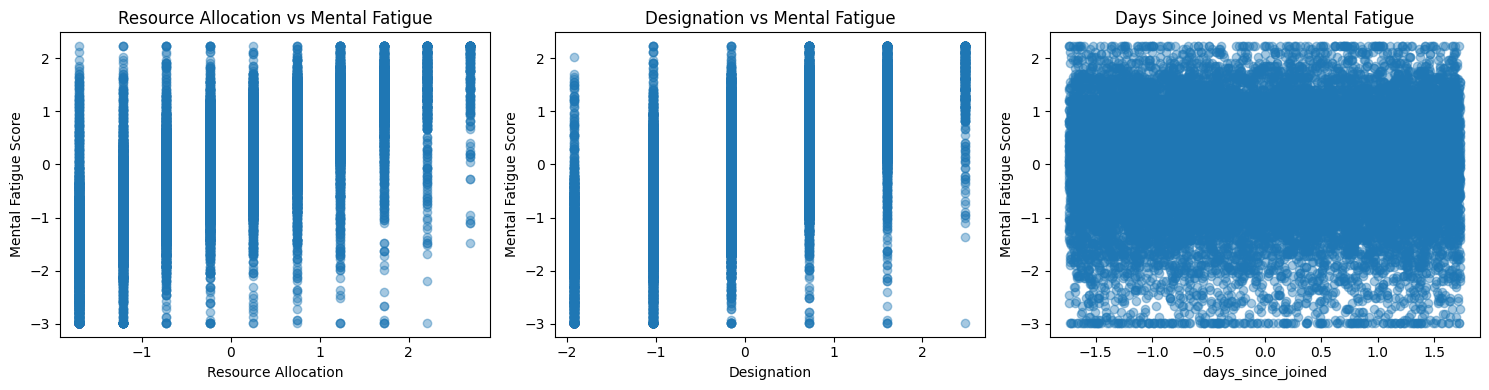

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Choose one cleaned dataset for EDA
eda_df = df_prob.copy()

# -----------------------------
# 1. Basic structure
# -----------------------------
print("Shape:", eda_df.shape)
print("\nData types:")
print(eda_df.dtypes)

print("\nSummary statistics:")
print(eda_df.describe())

print("\nMissing values:")
print(eda_df.isna().sum())

# -----------------------------
# 2. Distribution plots
# -----------------------------
numeric_cols = ["Designation", "Resource Allocation", "Mental Fatigue Score", "days_since_joined"]
eda_df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distributions of Continuous Features", y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Binary feature counts
# -----------------------------
binary_cols = ["gender", "company_type", "is_wfh"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(binary_cols):
    eda_df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Correlation matrix
# -----------------------------
corr = eda_df.corr(numeric_only=True)
print("\nCorrelation matrix:")
print(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Boxplots by binary groups
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_pairs = [
    ("gender", "Mental Fatigue Score"),
    ("company_type", "Mental Fatigue Score"),
    ("is_wfh", "Mental Fatigue Score"),
    ("is_wfh", "Resource Allocation")
]

for ax, (group_col, value_col) in zip(axes.flatten(), plot_pairs):
    eda_df.boxplot(column=value_col, by=group_col, ax=ax)
    ax.set_title(f"{value_col} by {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel(value_col)

plt.suptitle("")
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Scatterplots for clustering intuition
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(eda_df["Resource Allocation"], eda_df["Mental Fatigue Score"], alpha=0.4)
axes[0].set_title("Resource Allocation vs Mental Fatigue")
axes[0].set_xlabel("Resource Allocation")
axes[0].set_ylabel("Mental Fatigue Score")

axes[1].scatter(eda_df["Designation"], eda_df["Mental Fatigue Score"], alpha=0.4)
axes[1].set_title("Designation vs Mental Fatigue")
axes[1].set_xlabel("Designation")
axes[1].set_ylabel("Mental Fatigue Score")

axes[2].scatter(eda_df["days_since_joined"], eda_df["Mental Fatigue Score"], alpha=0.4)
axes[2].set_title("Days Since Joined vs Mental Fatigue")
axes[2].set_xlabel("days_since_joined")
axes[2].set_ylabel("Mental Fatigue Score")

plt.tight_layout()
plt.show()

EDA for df_median

Shape: (22750, 8)

Data types:
Designation             float64
Resource Allocation     float64
Mental Fatigue Score    float64
Burn Rate               float64
days_since_joined       float64
gender                    int64
company_type              int64
is_wfh                    int64
dtype: object

Summary statistics:
        Designation  Resource Allocation  Mental Fatigue Score     Burn Rate  \
count  2.275000e+04         2.275000e+04          2.275000e+04  21626.000000   
mean   2.011383e-16         5.902970e-17          1.975465e-16      0.452005   
std    1.000022e+00         1.000022e+00          1.000022e+00      0.198226   
min   -1.919379e+00        -1.737046e+00         -3.139028e+00      0.000000   
25%   -1.038415e+00        -7.306975e-01         -5.706123e-01      0.310000   
50%   -1.574506e-01        -2.275233e-01          8.515347e-02      0.450000   
75%    7.235137e-01         7.788253e-01          6.316250e-01      0.590000   
max    2.485442e+00         2.791523e+

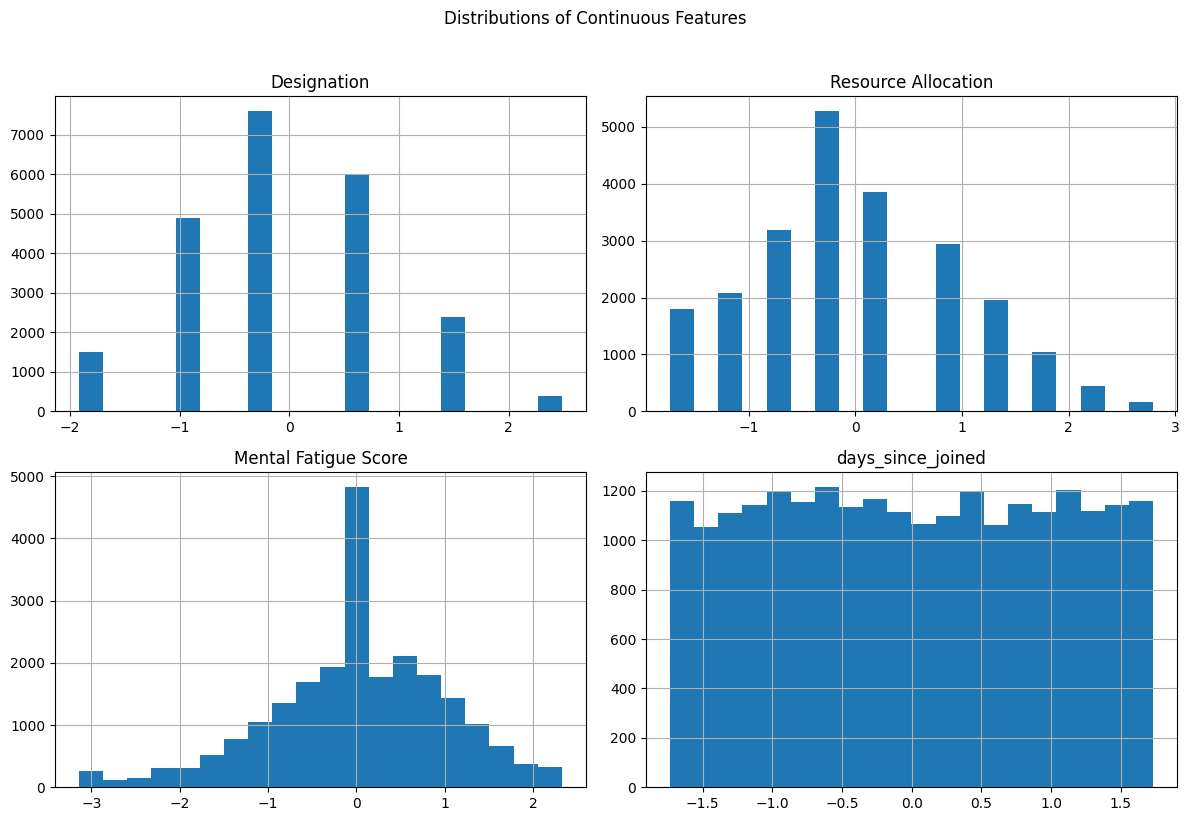

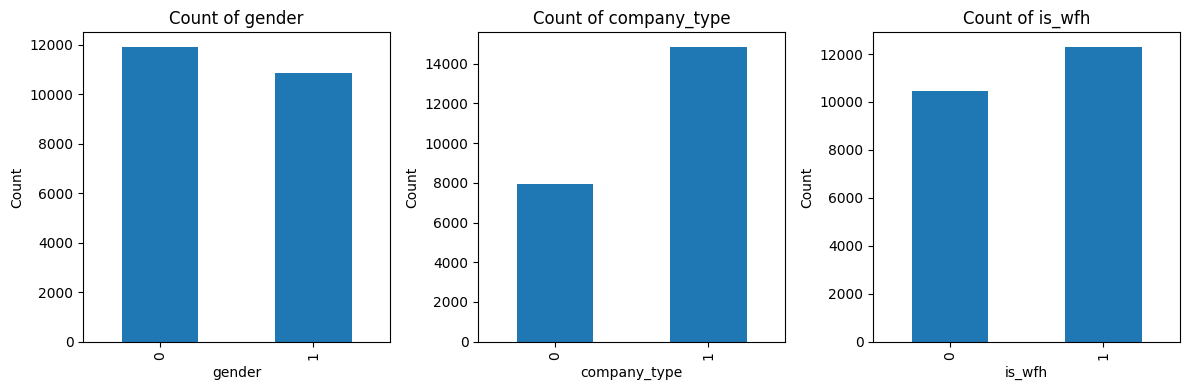


Correlation matrix:
                      Designation  Resource Allocation  Mental Fatigue Score  \
Designation              1.000000             0.850656              0.656316   
Resource Allocation      0.850656             1.000000              0.737823   
Mental Fatigue Score     0.656316             0.737823              1.000000   
Burn Rate                0.737556             0.829632              0.898926   
days_since_joined        0.000930             0.000612             -0.002255   
gender                   0.113295             0.138321              0.138519   
company_type             0.006095             0.006263              0.002347   
is_wfh                  -0.229720            -0.275692             -0.263203   

                      Burn Rate  days_since_joined    gender  company_type  \
Designation            0.737556           0.000930  0.113295      0.006095   
Resource Allocation    0.829632           0.000612  0.138321      0.006263   
Mental Fatigue Score   0

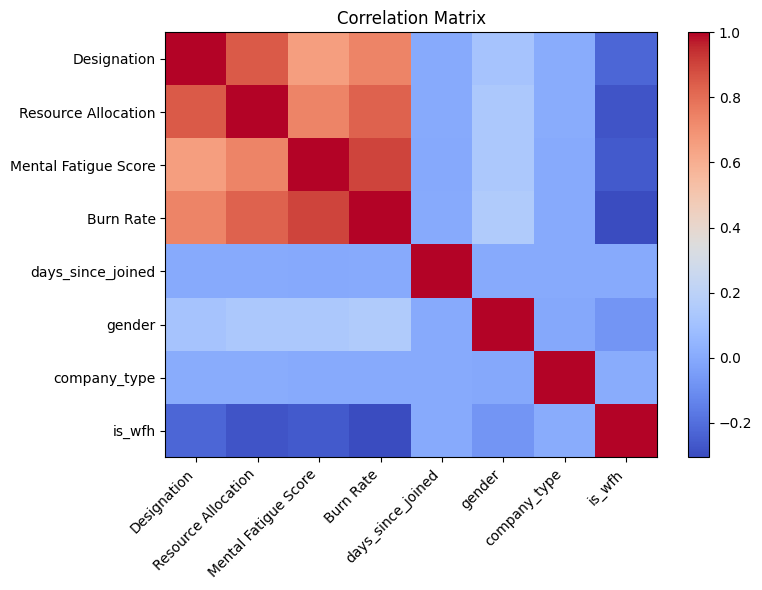

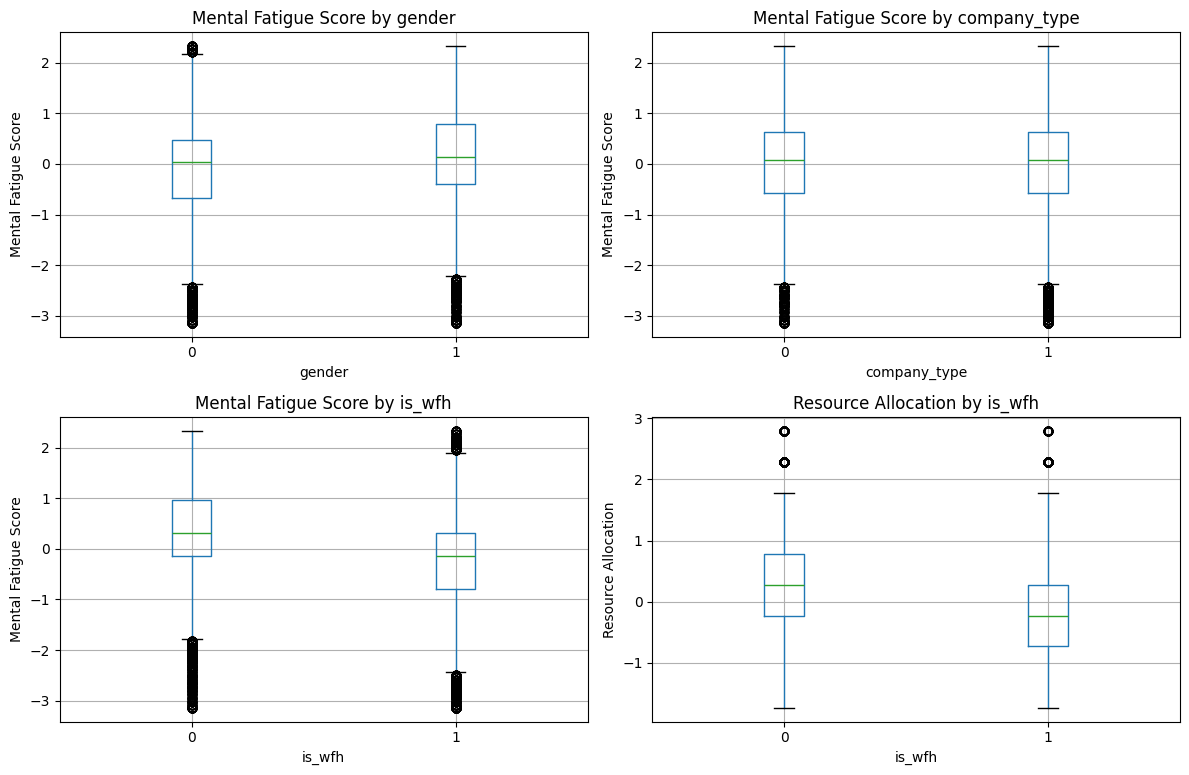

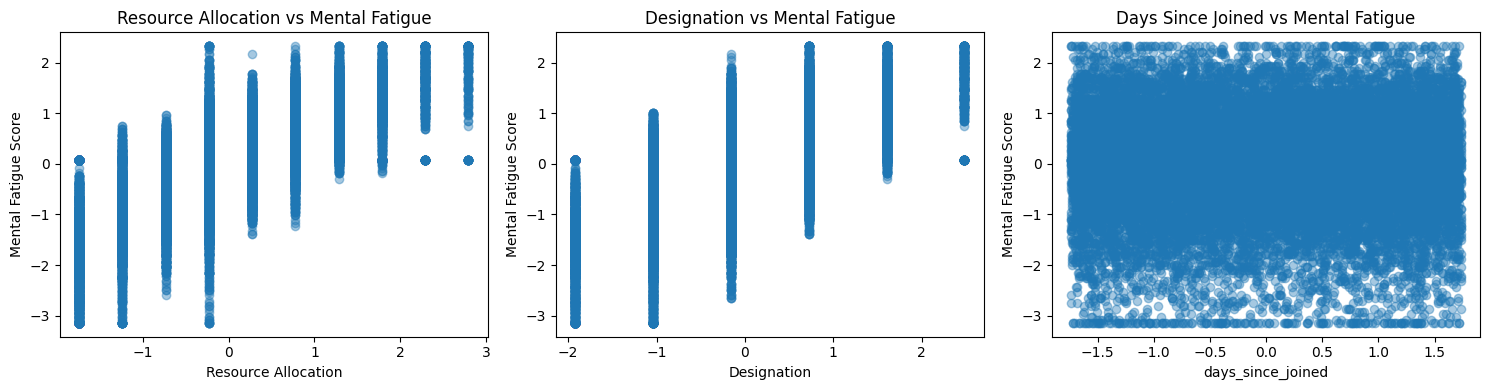

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Choose one cleaned dataset for EDA
eda_df = df_median.copy()

# -----------------------------
# 1. Basic structure
# -----------------------------
print("Shape:", eda_df.shape)
print("\nData types:")
print(eda_df.dtypes)

print("\nSummary statistics:")
print(eda_df.describe())

print("\nMissing values:")
print(eda_df.isna().sum())

# -----------------------------
# 2. Distribution plots
# -----------------------------
numeric_cols = ["Designation", "Resource Allocation", "Mental Fatigue Score", "days_since_joined"]
eda_df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distributions of Continuous Features", y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Binary feature counts
# -----------------------------
binary_cols = ["gender", "company_type", "is_wfh"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(binary_cols):
    eda_df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Correlation matrix
# -----------------------------
corr = eda_df.corr(numeric_only=True)
print("\nCorrelation matrix:")
print(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Boxplots by binary groups
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_pairs = [
    ("gender", "Mental Fatigue Score"),
    ("company_type", "Mental Fatigue Score"),
    ("is_wfh", "Mental Fatigue Score"),
    ("is_wfh", "Resource Allocation")
]

for ax, (group_col, value_col) in zip(axes.flatten(), plot_pairs):
    eda_df.boxplot(column=value_col, by=group_col, ax=ax)
    ax.set_title(f"{value_col} by {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel(value_col)

plt.suptitle("")
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Scatterplots for clustering intuition
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(eda_df["Resource Allocation"], eda_df["Mental Fatigue Score"], alpha=0.4)
axes[0].set_title("Resource Allocation vs Mental Fatigue")
axes[0].set_xlabel("Resource Allocation")
axes[0].set_ylabel("Mental Fatigue Score")

axes[1].scatter(eda_df["Designation"], eda_df["Mental Fatigue Score"], alpha=0.4)
axes[1].set_title("Designation vs Mental Fatigue")
axes[1].set_xlabel("Designation")
axes[1].set_ylabel("Mental Fatigue Score")

axes[2].scatter(eda_df["days_since_joined"], eda_df["Mental Fatigue Score"], alpha=0.4)
axes[2].set_title("Days Since Joined vs Mental Fatigue")
axes[2].set_xlabel("days_since_joined")
axes[2].set_ylabel("Mental Fatigue Score")

plt.tight_layout()
plt.show()